У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from darts.utils.statistics import check_seasonality
from statsmodels.tsa.seasonal import seasonal_decompose
from darts import TimeSeries
from darts.models import NaiveDrift, NaiveSeasonal, ExponentialSmoothing, AutoARIMA, XGBModel, ARIMA, Prophet, RNNModel
from darts.metrics import mape
from darts.dataprocessing.transformers import Scaler
from darts import concatenate
from darts.utils.statistics import plot_hist

In [2]:
data = pd.read_csv('train.csv.zip')
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)

data.head(10)

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



<Axes: xlabel='item'>

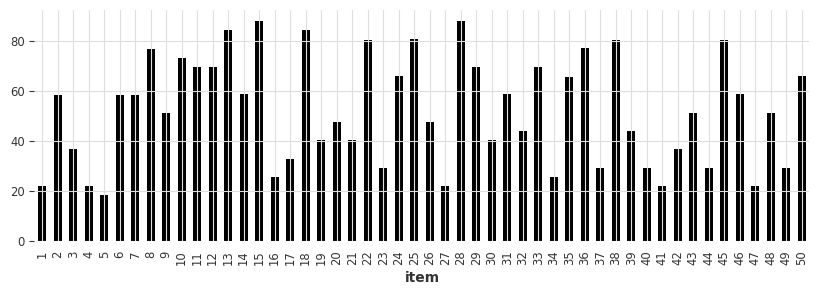

In [4]:
plt.figure(figsize=(10, 3))
data.groupby(by='item')['sales'].mean().plot(kind='bar')

In [5]:
# Групую дані за товаром та обчислюю стандартне відхилення
grouped_data = data.groupby('item')['sales'].agg(['mean', 'std']).round(2)

# Обчислюю відсоток стандартного відхилення відносно середнього значення
grouped_data['std_pct'] = ((grouped_data['std'] / grouped_data['mean']) * 100).round(2)

# Вивід результатів
grouped_data

,mean,std,std_pct
item,,,
1,21.98,8.47,38.54
2,58.57,20.09,34.30
3,36.64,13.18,35.97
4,22.01,8.40,38.16
5,18.36,7.27,39.60
6,58.50,20.17,34.48
7,58.53,20.15,34.43
8,76.95,26.13,33.96
9,51.39,17.79,34.62


In [6]:
grouped_data['std_pct'].min(), grouped_data['std_pct'].max()

(33.53, 39.6)

In [7]:
grouped_data['mean'].idxmin(), grouped_data['mean'].idxmax()

(5, 15)

<Axes: xlabel='item'>

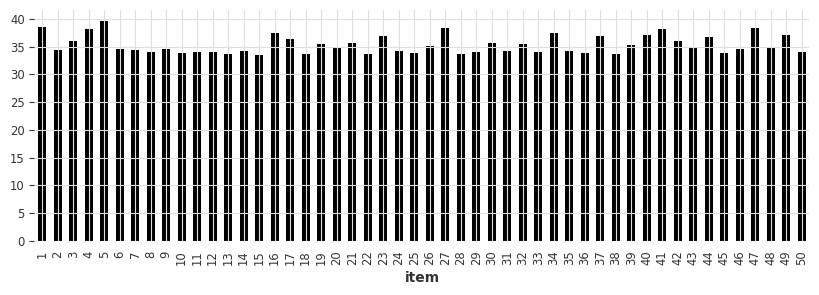

In [8]:
plt.figure(figsize=(10, 3))
grouped_data.std_pct.plot(kind='bar')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


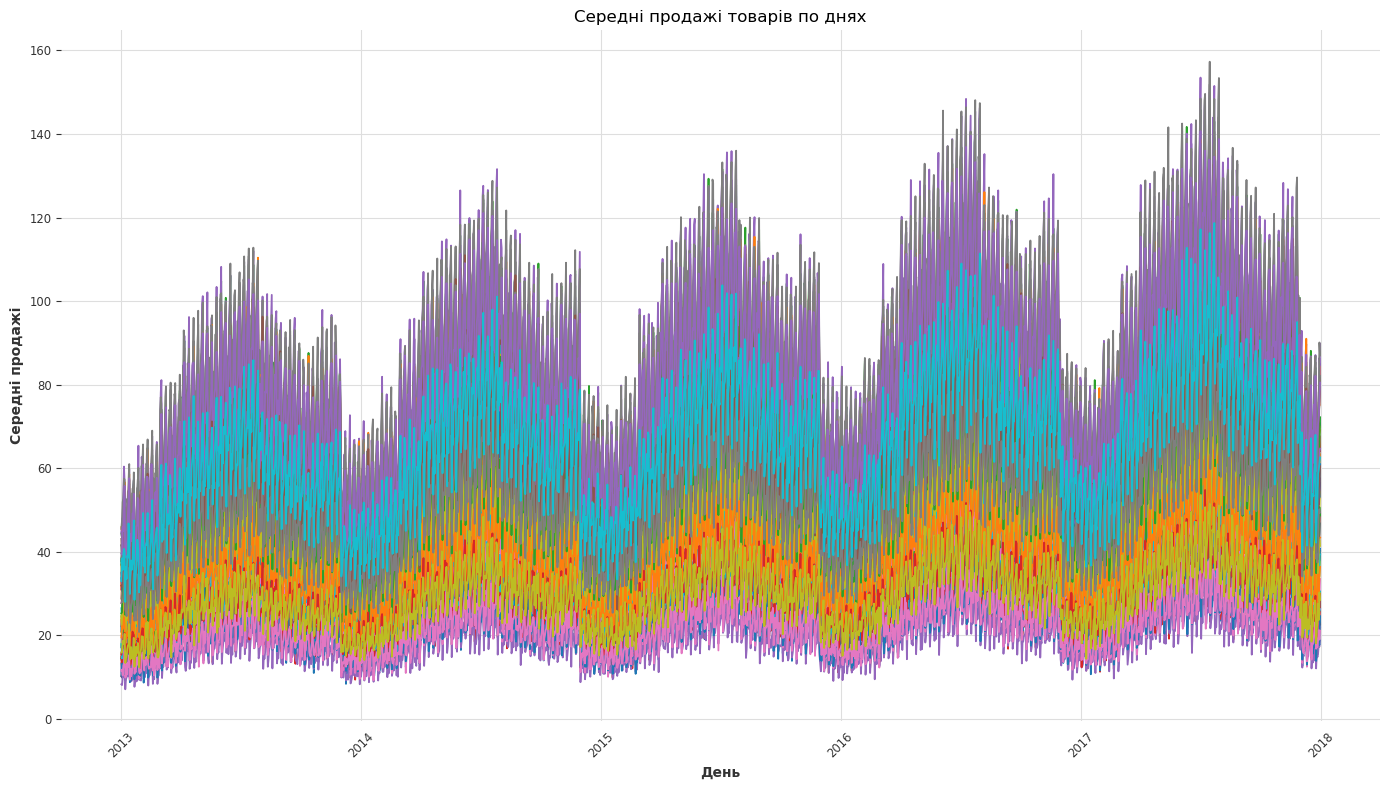

In [10]:
# Обчислюю середнє значення продажів по кожному товару для кожного дня
item_sales_day = data.groupby(['date', 'item'])['sales'].mean().reset_index()

# Створюю лінійний графік
plt.figure(figsize=(14, 8))
sns.lineplot(data=item_sales_day, x='date', y='sales', hue='item', palette='tab10', legend=False)
plt.title('Середні продажі товарів по днях')
plt.xlabel('День')
plt.ylabel('Середні продажі')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

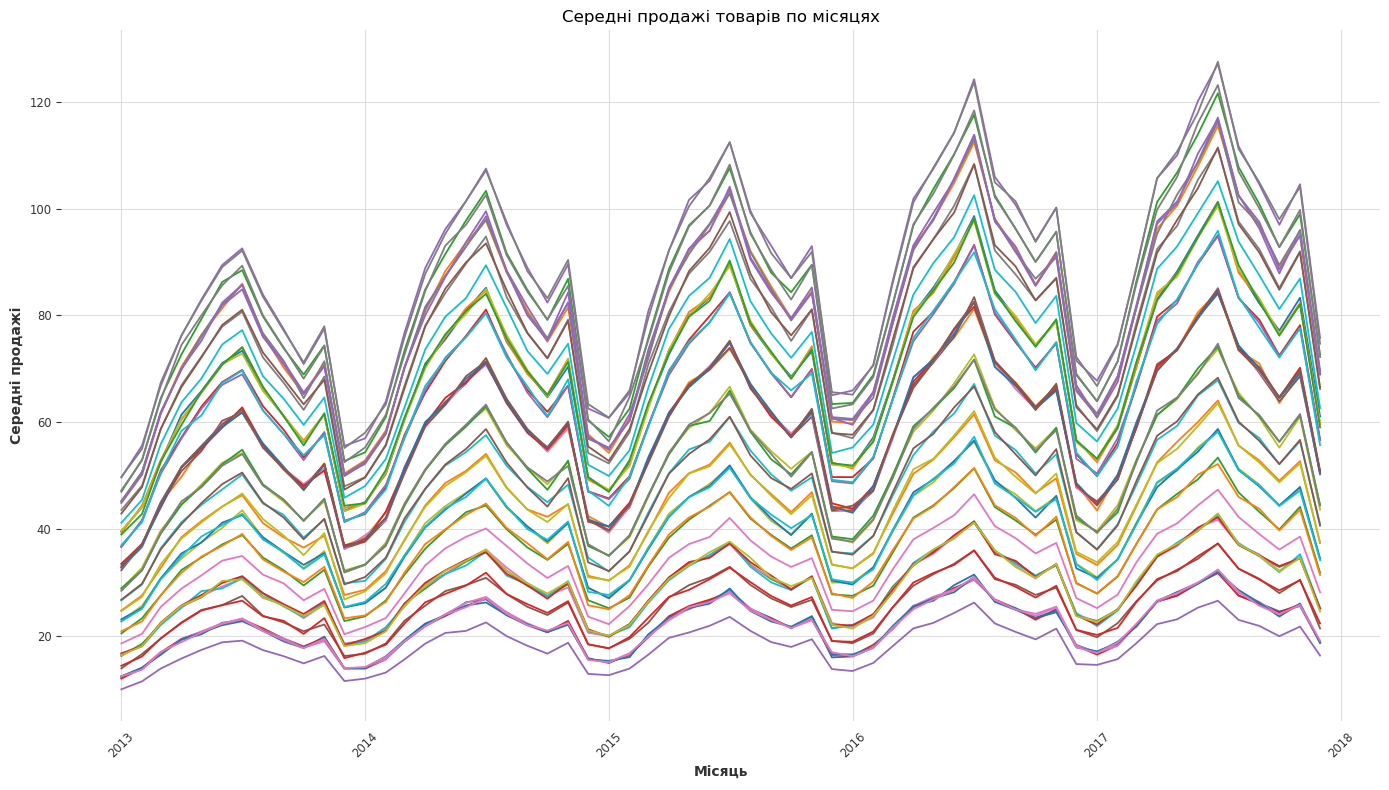

In [11]:
# Додаю стовпець з місяцем
data['month'] = data.index.to_period('M').start_time

# Обчислюю середнє значення продажів по кожному товару для кожного тижня
item_sales_weekly = data.groupby(['month', 'item'])['sales'].mean().reset_index()

# Створюю лінійний графік
plt.figure(figsize=(14, 8))
sns.lineplot(data=item_sales_weekly, x='month', y='sales', hue='item', palette='tab10', legend=False)
plt.title('Середні продажі товарів по місяцях')
plt.xlabel('Місяць')
plt.ylabel('Середні продажі')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Спостереження:** Товар 1 має стандартне відхилення `38,54 %`, що вказує на те, що продажі цього товару в різних магазинах відхиляються від середнього приблизно на `38,54 %`. Вищі відсотки `std_pct` означають більшу варіативність продажів у магазинах, тоді як нижчі відсотки означають стабільніші продажі. Ця відносна міра мінливості може бути корисною для порівняння сталості продажів різних товарів, навіть якщо їхні середні значення продажів значно відрізняються.

Загалом, стандартні відхилення свідчать про те, що продажі товарів досить сильно відрізняються між усіма магазинами. Це означає, що немає товарів з дуже стабільними продажами у всіх магазинах.

Різниця між мінімальним та максимальним стандартним відхиленням досить невелика (близько `6%`). Мінімальне стандартне відхилення по усіх товарах `33,53 %`, максимальне `39,6 %`, що вказує на те, що не має товарів з високою або низькою варіабельністю в порівнянні з іншими.

Графік `Середні продажі товарів` по днях показує зростаючий загальний тренд у продажах товарів. Це може вказувати на збільшення попиту або успішний маркетинг.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [12]:
data_item1_store1 = data.query('item == 1 and store == 1')
data_item1_store1 = data_item1_store1.sort_index()

In [13]:
# Визначення дати для початку останніх двох років
end_date = data_item1_store1.index.max()
start_date = end_date - pd.DateOffset(years=2)

In [14]:
# Фільтрація даних за останні два роки
data_last_two_years = data_item1_store1.loc[start_date:end_date]

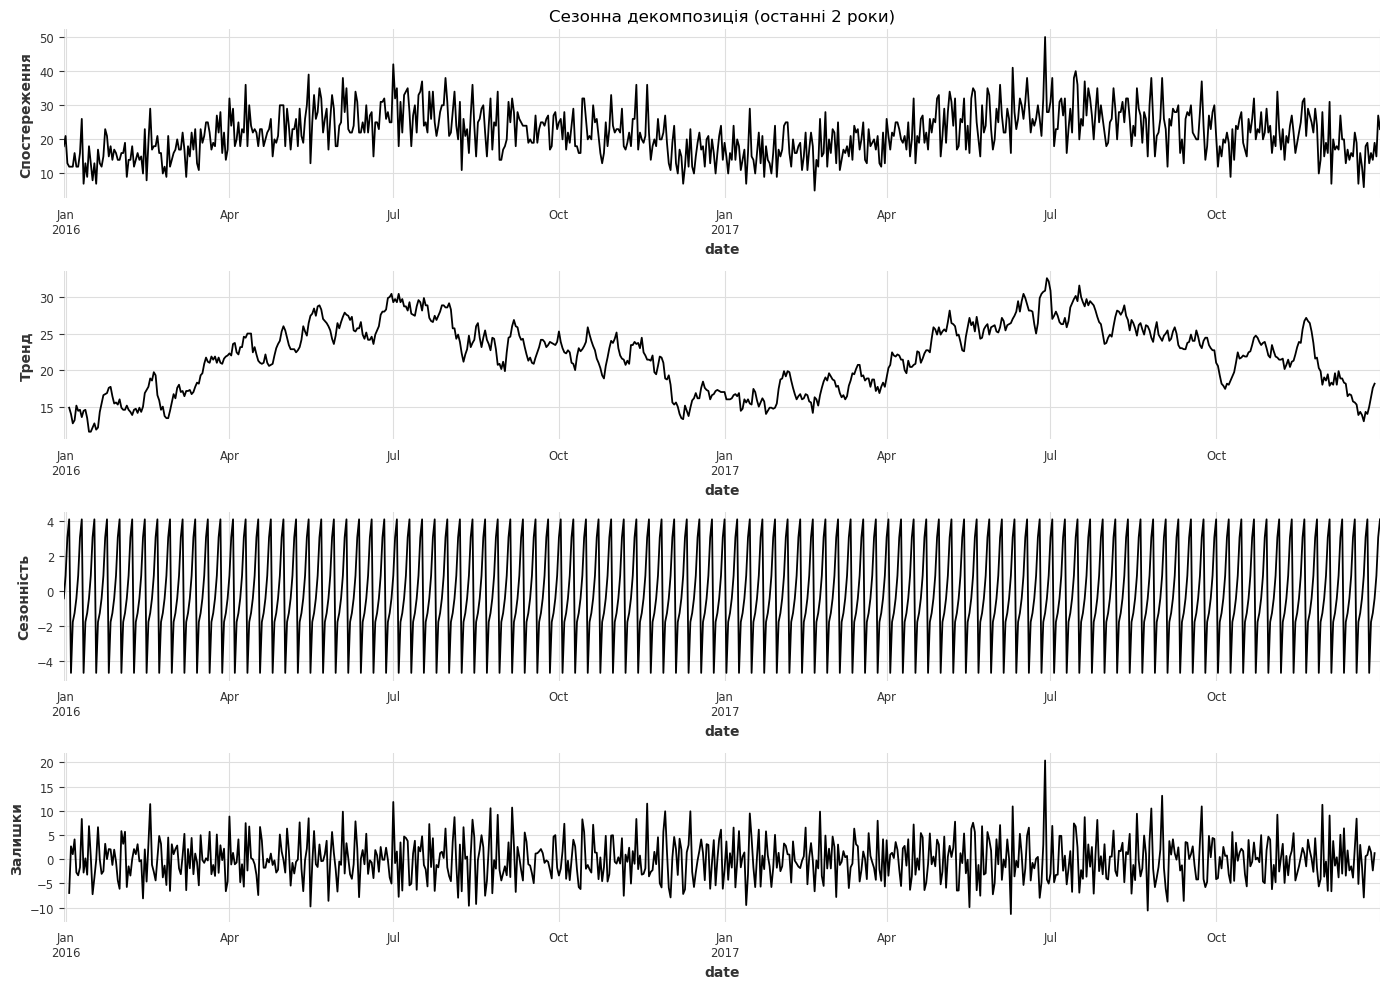

In [15]:
# Розкладання даних
decomposition = seasonal_decompose(data_last_two_years['sales'], model='additive')

# Візуалізація результатів
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], legend=False)
axes[0].set_ylabel('Спостереження')
axes[0].set_title('Сезонна декомпозиція (останні 2 роки)')

decomposition.trend.plot(ax=axes[1], legend=False)
axes[1].set_ylabel('Тренд')

decomposition.seasonal.plot(ax=axes[2], legend=False)
axes[2].set_ylabel('Сезонність')

decomposition.resid.plot(ax=axes[3], legend=False)
axes[3].set_ylabel('Залишки')

plt.tight_layout()
plt.show()

**Спостереження:** З отриманих графіків видно, що є тижнева сезонність. Залишки зосереджені навколо нуля. Для покращення інтерпретованості графіків можна застосуати агрегацію даних або вивести ще менший проміжок (наприклад, лише останній рік).

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [16]:
series = TimeSeries.from_dataframe(data_item1_store1, value_cols='sales')

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

<Axes: xlabel='date'>

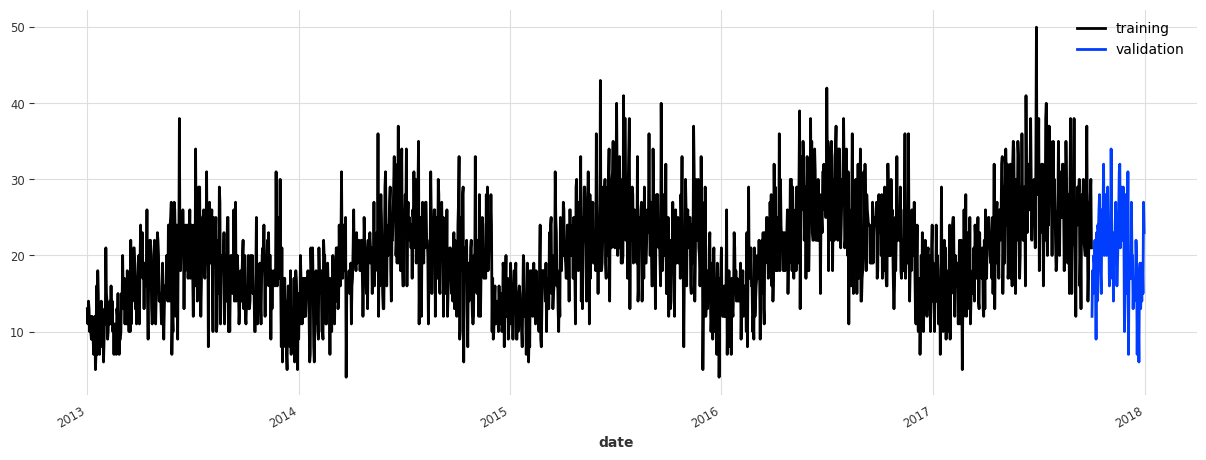

In [17]:
train, val = series.split_after(pd.Timestamp("2017-10-01"))
plt.figure(figsize=(15, 5))
train.plot(label="training")
val.plot(label="validation")

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

<Figure size 1000x600 with 0 Axes>

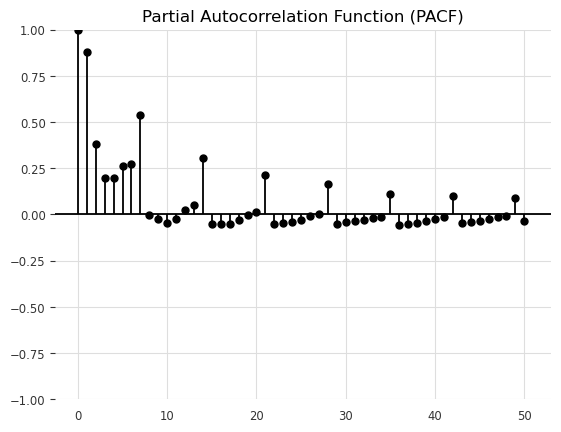

In [18]:
# Візуалізація часткової автокореляційної функції (PACF)
plt.figure(figsize=(10, 6))
plot_pacf(data['sales'], lags=50, method='ywm')
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

**Спостереження:** З графіка часткової автокореляційної функції помітно, що лаги кратні 7 є важливими для прогнозування. 

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [19]:
for m in range(2, 25):
    is_seasonal, period = check_seasonality(train, m=m, alpha=0.05)
    if is_seasonal:
        print("There is seasonality of order {}.".format(period))

There is seasonality of order 7.
There is seasonality of order 14.
There is seasonality of order 21.


8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

<Axes: xlabel='date'>

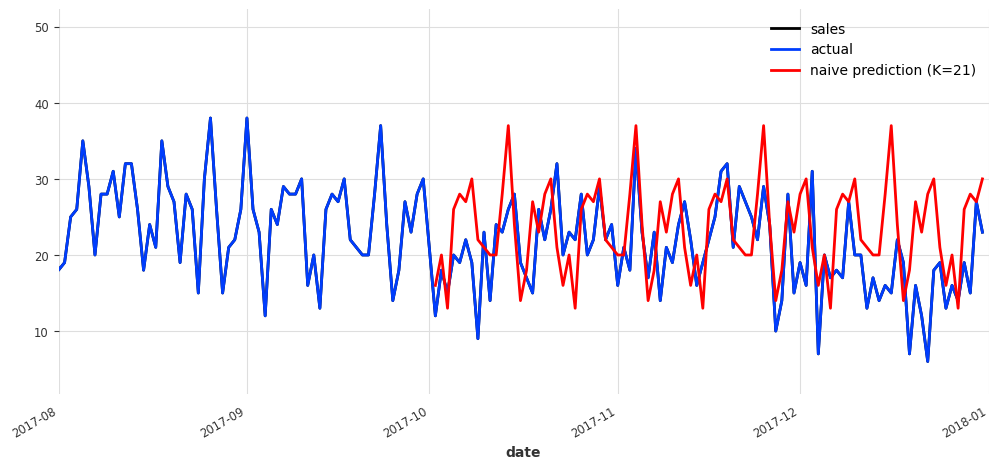

In [20]:
seasonal_model = NaiveSeasonal(K=21)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(91)

plt.figure(figsize=(12, 5))
series.plot()
plt.xlim(left=pd.Timestamp('2017-08-01'), right=pd.Timestamp('2018-01-01'))
series.plot(label="actual")
seasonal_forecast.plot(label="naive prediction (K=21)", color='red')

<Axes: xlabel='date'>

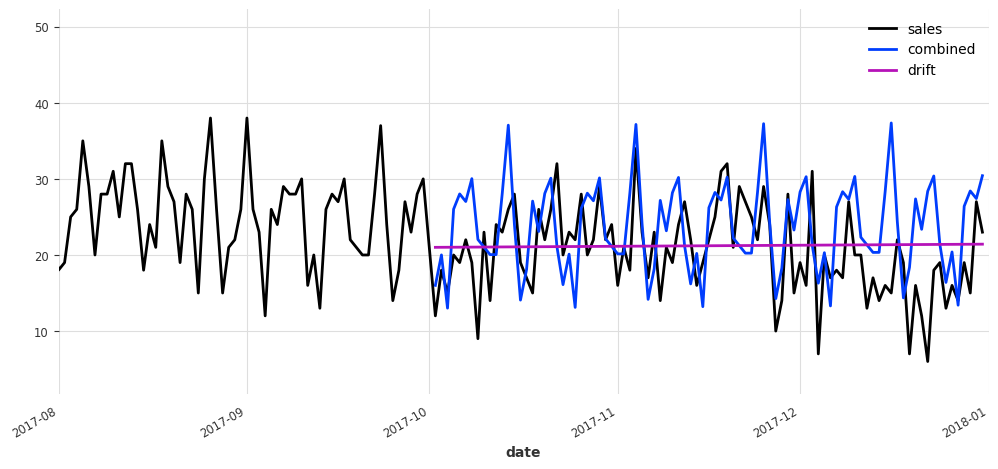

In [21]:
drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(91)

combined_forecast = drift_forecast + seasonal_forecast - train.last_value()


plt.figure(figsize=(12, 5))
series.plot()
plt.xlim(left=pd.Timestamp('2017-08-01'), right=pd.Timestamp('2018-01-01'))
combined_forecast.plot(label="combined")
drift_forecast.plot(label="drift")

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [22]:
print(
    f"Mean absolute percentage error for the combined naive drift + seasonal: {mape(series, combined_forecast):.2f}%."
)

Mean absolute percentage error for the combined naive drift + seasonal: 38.48%.


10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [23]:
def enrich_with_date_features(df):
  # Feature Extraction
  df["dayofweek"] = df['date'].dt.dayofweek
  df["quarter"] = df['date'].dt.quarter
  df["month"] = df['date'].dt.month
  df["year"] = df['date'].dt.year
  df["dayofyear"] = df['date'].dt.dayofyear
  df["sin_day"] = np.sin(df["dayofyear"])
  df["cos_day"] = np.cos(df["dayofyear"])
  df["dayofmonth"] = df['date'].dt.day
  return df

# Додавання ознак дати
train_transformed = enrich_with_date_features(train.pd_dataframe().reset_index())
val_transformed = enrich_with_date_features(val.pd_dataframe().reset_index())

# Масштабування даних
scaler = Scaler()
train_transformed = scaler.fit_transform(train)
test_transformed = scaler.transform(val)

# Побудова моделі XGBoost
model = XGBModel(
    lags=70,  # Використання останніх 70 спостережень для прогнозування
    output_chunk_length=1,  # Прогнозування на 1 крок вперед
    n_estimators=200,  # Кількість дерев у моделі
    max_depth=3,  # Максимальна глибина кожного дерева
    learning_rate=0.1,  # Коефіцієнт навчання
    subsample=0.8,  # Частка даних для випадкової вибірки кожного дерева
    colsample_bytree=0.8  # Частка ознак, що використовуються для кожного дерева
)

# Тренування моделі
model.fit(train_transformed)
pred = model.predict(6)
pred.values()

array([[0.32692352],
       [0.3552644 ],
       [0.44588405],
       [0.38409212],
       [0.54411304],
       [0.5312447 ]], dtype=float32)

In [24]:
def eval_forecast(model, val, forecast):
    mape_ = mape(val, forecast)
    print(f'model {model} obtains MAPE: {mape_:.2f}%')
    return mape_

def fit_eval_model(model):
    model.fit(train)
    forecast = model.predict(len(val))
    eval_forecast(model, val, forecast)

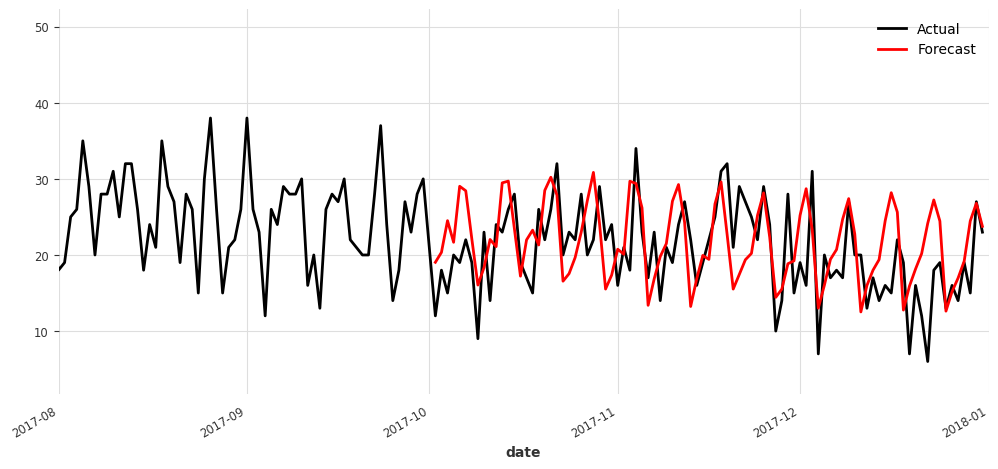

In [25]:
forecast = scaler.inverse_transform(model.predict(len(val)))

plt.figure(figsize=(12, 5))
plt.xlim(left=pd.Timestamp('2017-08-01'), right=pd.Timestamp('2018-01-01'))
series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()

In [26]:
eval_forecast(model, val, forecast);

model XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...) obtains MAPE: 31.02%


**Спостереження:** XBGModel дає трохи кращі результати (MAPE: `31.02%`), ніж combined naive drift + seasonal (MAPE: `38.48%`). Моделі добре вловлюють сезонність, але взанальному погано передбачають. 

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

In [27]:
def plot_results(series, forecast):
    # Візуалізація результатів
    plt.figure(figsize=(12, 5))
    plt.xlim(left=pd.Timestamp('2017-08-01'), right=pd.Timestamp('2018-01-01'))
    series.plot(label='Actual')
    forecast.plot(label='Forecast', color='red')
    plt.legend()
    plt.show()


def fit_and_plot(model, series, train, val):
    model.fit(train)
    forecast = model.predict(len(val))
    plot_results(series, forecast)
    eval_forecast(model, val, forecast);

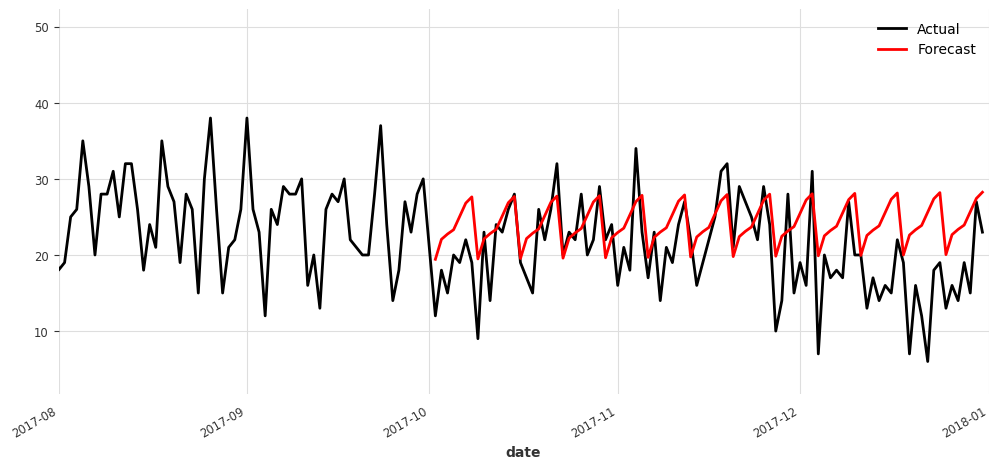

model ExponentialSmoothing() obtains MAPE: 36.15%


In [28]:
model = ExponentialSmoothing()
fit_and_plot(model, series, train, val)

**Спостереження:** ExponentialSmoothing дає трохи кращі результати (MAPE: `36.15%`), ніж combined naive drift + seasonal (MAPE: `38.48%`), але гірші, ніж XBGModel (MAPE: `31.02%`). Модель знову з таки занадто вловила сезонні коливання в даних, але не змогла відтворити інші компоненти часового ряду.

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

C:\Users\Anastasiia\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Anastasiia\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Anastasiia\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


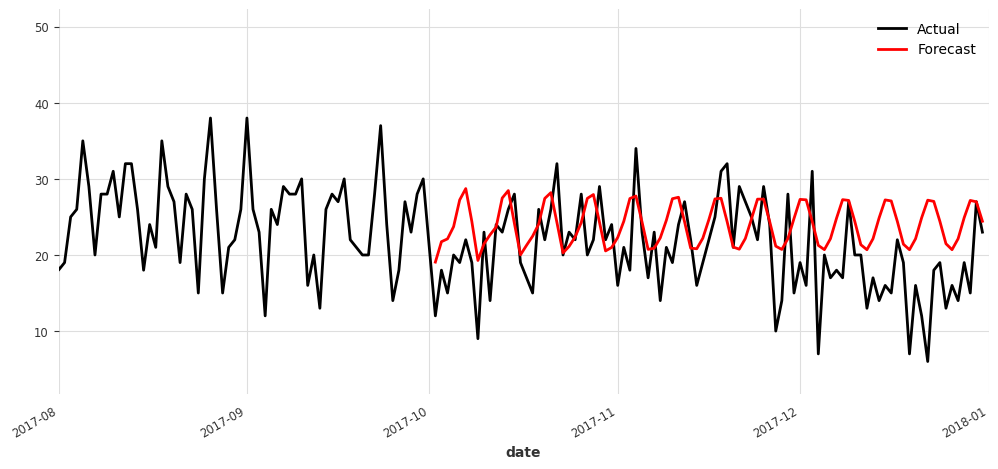

model ARIMA(p=14, q=7) obtains MAPE: 37.06%


In [29]:
# Побудова та тренування моделі ARIMA
model = ARIMA(p=14, d=1, q=7)
fit_and_plot(model, series, train, val)

**Спостереження:** ARIMA дає найслабші результати (MAPE: `37.06%`).

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

AutoARIMA(add_encoders=None, start_p=5, start_q=1, max_p=40, max_q=1, seasonal=True)

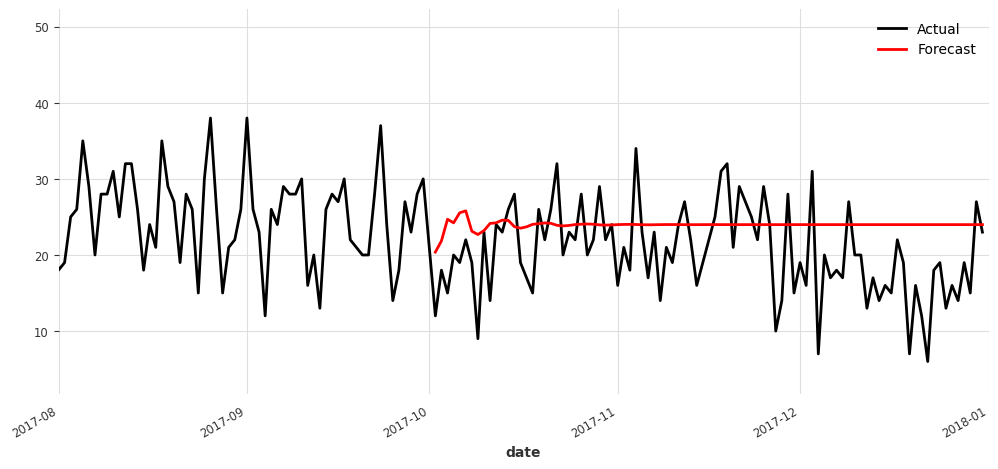

model AutoARIMA(start_p=5, start_q=1, max_p=40, max_q=1, seasonal=True) obtains MAPE: 38.61%


In [30]:
# Побудова та тренування моделі AutoArima
model = AutoARIMA(start_p=5, start_q=1, max_p=40, max_q=1, seasonal=True)
model.fit(train)

display(model)

# Прогнозування
forecast = model.predict(len(val))

# Візуалізація результатів
fit_and_plot(model, series, train, val)

In [31]:
# Вивід інформації про модель
print("ARIMA model summary:")
print(model.model.summary())

ARIMA model summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1735
Model:               SARIMAX(7, 1, 1)   Log Likelihood               -5289.284
Date:                Sun, 18 Aug 2024   AIC                          10596.568
Time:                        18:50:35   BIC                          10645.692
Sample:                             0   HQIC                         10614.736
                               - 1735                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0343      0.038      0.897      0.369      -0.041       0.109
ar.L2         -0.0800      0.034     -2.379      0.017      -0.146      -0.014
ar.L3         -0.0774      0.03

In [32]:
eval_forecast(model, val, forecast); 

model AutoARIMA(start_p=5, start_q=1, max_p=40, max_q=1, seasonal=True) obtains MAPE: 38.61%


**Спостереження:** AutoARIMA вивела наступні найкращі параметри: (7, 1, 1). Ця модель дає слабші результати (MAPE: `38.61%`) порівняно з попереднім експериментом. 

14. Натренуйте модель Prophet та зробіть висновок про її якість.

18:50:35 - cmdstanpy - INFO - Chain [1] start processing
18:50:35 - cmdstanpy - INFO - Chain [1] done processing
18:50:35 - cmdstanpy - INFO - Chain [1] start processing
18:50:35 - cmdstanpy - INFO - Chain [1] done processing


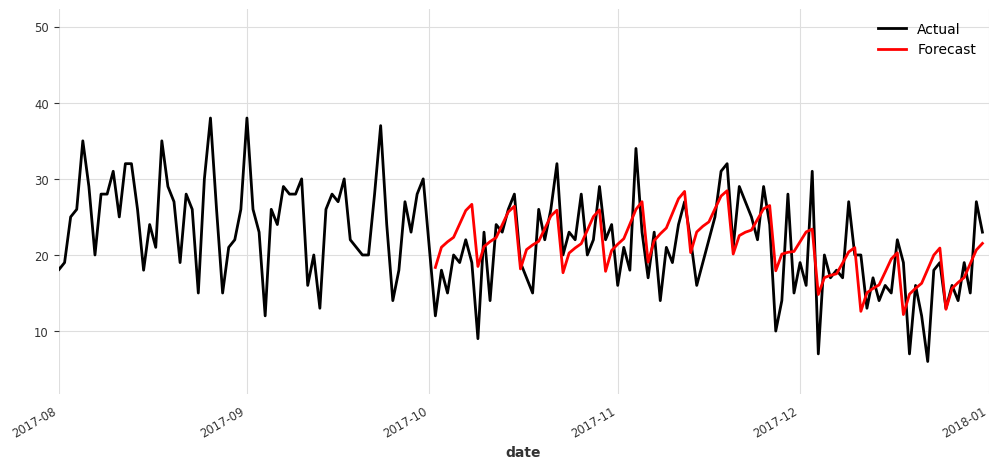

model Prophet() obtains MAPE: 23.64%


In [33]:
# Побудова та тренування моделі Prophet
model = Prophet()
model.fit(train)

# Прогнозування
forecast = model.predict(len(val))

# Візуалізація результатів
fit_and_plot(model, series, train, val)

In [34]:
eval_forecast(model, val, forecast);

model Prophet() obtains MAPE: 23.64%


**Спостереження:** Prophet дала найкращі результати (MAPE: `23.64%`). Ця модель як і попередні добре вловила тижневу сезонність, а також краще враховує більш довгострокові коливанння в даних.

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

In [35]:
# Побудова та тренування моделі RNN
model = RNNModel(
    model="LSTM",
    input_chunk_length=21,
    hidden_dim=20,
    dropout=0,
    batch_size=16,
    n_epochs=50,
    optimizer_kwargs={"lr": 1e-3},
    log_tensorboard=True,
    random_state=29,
    training_length=21,
    force_reset=True,
)

In [36]:
# Навчання моделі на тренувальній вибірці
model.fit(train)

# Прогнозування
forecast = model.predict(n=len(val), series=train)

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
C:\Users\Anastasiia\anaconda3\Lib\site-packages\pytorch_lightning\trainer\setup.py:176: PossibleUserWarning: GPU available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='gpu', devices=1)`.
  rank_zero_warn(

  | Name            | Type             | Params
-----------------------------------------------------
0 | criterion       | MSELoss          | 0     
1 | train_criterion | MSELoss          | 0     
2 | val_criterion   | MSELoss          | 0     
3 | train_metrics   | MetricCollection | 0     
4 | val_metrics     | MetricCollection | 0     
5 | rnn             | LSTM             | 1.8 K 
6 | V               | Linear           | 21    
-----------------------------------------------------
1.9 K     Trainable params
0         Non-trainable params
1.9 K     Total params
0.015     Total estimated model params 

Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
C:\Users\Anastasiia\anaconda3\Lib\site-packages\pytorch_lightning\trainer\setup.py:176: PossibleUserWarning: GPU available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='gpu', devices=1)`.
  rank_zero_warn(


Predicting: 0it [00:00, ?it/s]

In [37]:
eval_forecast(model, val, forecast);

model RNNModel(model=LSTM, hidden_dim=20, training_length=21, input_chunk_length=21, batch_size=16, n_epochs=50, optimizer_kwargs={'lr': 0.001}, log_tensorboard=True, random_state=29, force_reset=True) obtains MAPE: 37.37%


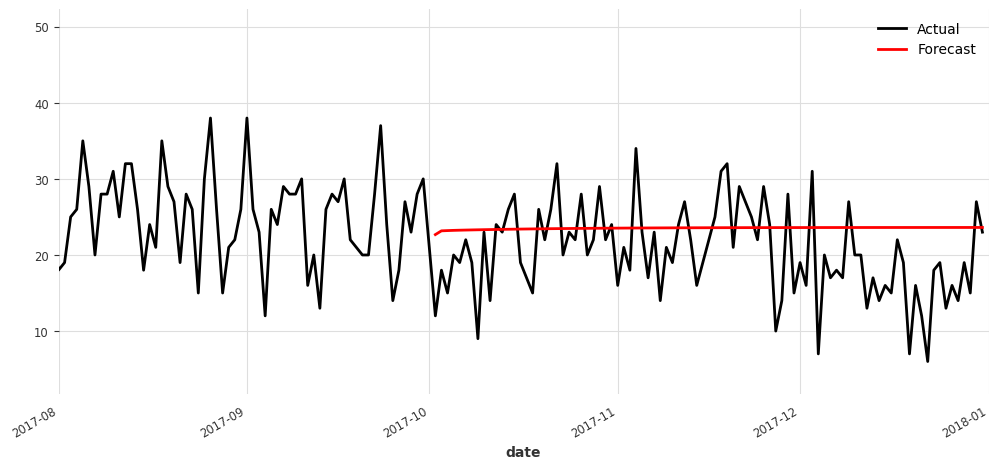

In [38]:
# Візуалізація результатів
plt.figure(figsize=(12, 5))
plt.xlim(left=pd.Timestamp('2017-08-01'), right=pd.Timestamp('2018-01-01'))
series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()

**Спостереження:** RNNModel дала результати MAPE: `37.37%`.

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

In [54]:
# наша найкраща модель
model = Prophet()
model.fit(train)

forecast = model.predict(len(val))
eval_forecast(model, val, forecast);

18:57:43 - cmdstanpy - INFO - Chain [1] start processing
18:57:43 - cmdstanpy - INFO - Chain [1] done processing


model Prophet() obtains MAPE: 23.64%


In [56]:
hfc_params = {
    "series": series,
    "forecast_horizon": 30,  # Прогноз на 1 місяць
    "train_length": 365,     # Довжина тренувальної вибірки - 1 рік
    "verbose": True,
    "retrain": True,          # Перенавчання моделі для кожного нового прогнозу
    "stride": 30
    }

In [ ]:
# Виконання історичних прогнозів
historical_fcast_all = model.historical_forecasts(last_points_only=False, **hfc_params)

In [ ]:
raw_errors = model.backtest(metric=mape, reduction=None, last_points_only=False, **hfc_params)

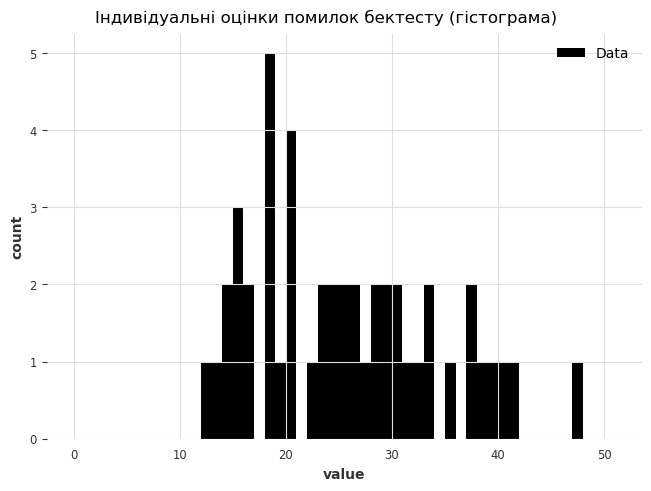

In [62]:
plot_hist(
    raw_errors,
    bins=np.arange(0, max(raw_errors), 1),
    title="Індивідуальні оцінки помилок бектесту (гістограма)",
)

In [ ]:
average_error = model.backtest(
    metric=mape,
    reduction=np.mean,  # this is actually the default
    **hfc_params
)

In [63]:
print(f"Average error (MAPE) over all historical forecasts: {average_error:.2f}")

Average error (MAPE) over all historical forecasts: 26.13


Всю варіантивність не вгадали, але виглядає непогано!

**Спостереження:** Більшість значень помилок зосереджені в діапазоні від 10 до 25. Це вказує на те, що для більшості прогнозів помилка складає від 10% до 25%. Відсутні помилки у діапазоні менше 10, це може вказувати на те, що моделі складно досягати високої точності.  Є декілька випадків, де помилки досить великі, зокрема помилки понад із значеннями 40.

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

**Висновок:** Я би будувала індивідуальні моделі для кожної комбінації магазин-товару. Спершу я би написала функції у які можна було б передавати номер товару та номер магазину, а також параметри для моделі, щоб налаштовувати її точніше під особливості конкретного магазину і товару.

Я б обрала модель Prophet, яка показала найкращі результати на першому товарі першого магазину, оскільки з спостережень і аналізу у пункті 2 вияснила, що товари мають однакові сезонні коливання і взагальному їх поведінка протягом усього періоду не сильно відрізняється, тому я думаю, що можна викристати одну модель для аналізу кожного окремого товару. 